# Data Samples

This notebook shows how to deal with the data samples and reports the available ones.
All the following samples have been produced with an [AnalysisProduction](https://lhcb-ap.docs.cern.ch/)(AP) to create the tuples and store them on the GRID.
For simplicity a file for each sample has been saved to disk on the `pearly-gates` server for a preliminary analysis.

Once the preliminary analysis is done, another AP with a refined selection will be prepared.

## Data

Data has been recorded by the LHCb detector during Run3 of LHC (2024-2026).
In these files, the candidates passing the HLT2 $\tau\to\mu\mu\mu$ and $D^+_s\to\phi(\mu\mu)\pi^+$ lines are saved by recording a certain number of kinematic, particle identification, and isolation variables (it should be noted that isolation variables are not available for the first part of 2024).

In [1]:
import os
import uproot
import yaml
from importlib.resources import files

In [2]:
data_samples = yaml.safe_load(open('../data/testing_ap.yaml', 'r'))
print(data_samples)

{'data': ['/data02/gr1/lhcb/tesi/impicciche/data/24c4a/mu/00407866_00000001_1.dvtuple_tau_to_mumumu.root'], 'mc-21513012': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/21513012/00407827_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-21513013': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/21513013/00407819_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23173002': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23173002/00407855_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23173003': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23173003/00407843_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23513015': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23513015/00407811_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23513016': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23513016/00407799_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-31113003': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/31113003/00407835_00000001_1.dvtuple_tau_to_mumumu_mc.root']}


In [3]:
data = uproot.open(data_samples['data'][0])
print(data.keys())

['Tau2MuMuMu;1', 'Tau2MuMuMu/DecayTree;6', 'Ds2PhiPi;1', 'Ds2PhiPi/DecayTree;1', 'lumiTree;1', 'FileSummaryRecord;1']


In the data files there are a couple of `DecayTree` objects:
- Tau2MuMuMu/DecayTree
- Ds2PhiPi/DecayTree

The first one is obtained from candidates selected by the $\tau\to\mu\mu\mu$ line, and the second by the $D^+_s\to\phi(\mu\mu)\pi^+$ one.
To inspect the tree contents, use the [uproot](https://uproot.readthedocs.io/en/latest/) package.

### $\tau \to \mu\mu\mu$ candidate

In [4]:
data['Tau2MuMuMu/DecayTree'].keys()

['totCandidates',
 'nCandidate',
 'ALLPVCHI2_indx',
 'ALLPVCHI2',
 'ALLPVNDOF_indx',
 'ALLPVNDOF',
 'ALLPVX_indx',
 'ALLPVX',
 'ALLPVY_indx',
 'ALLPVY',
 'ALLPVZ_indx',
 'ALLPVZ',
 'BUNCHCROSSING_ID',
 'BUNCHCROSSING_TYPE',
 'BeamspotX',
 'BeamspotY',
 'BeamspotZ',
 'EVENTNUMBER',
 'FillNumber',
 'GPSTIME',
 'Hlt1BeamGasDecision',
 'Hlt1BeamOneDecision',
 'Hlt1BeamTwoDecision',
 'Hlt1BothBeamsDecision',
 'Hlt1GECPassthroughDecision',
 'Hlt1L02PPiDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice1_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice1_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice2_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice2_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice3_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice3_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice4_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice4_promptDecision',
 'Hlt1LowMassNoipDielectron_massSlice1_displacedDecisio

Since the tuples are relatively large, it is advisable to create `numpy` arrays or `pandas` dataframes with a limited number of variables or entries to perform specific tasks.

For example, to plot the mass and transverse momentum distribution of the $\tau$ candidate, the fastest option is:

In [5]:
import pandas as pd

In [6]:
variables_to_plot = ['Tau_M', 'Tau_PT']
df = data['Tau2MuMuMu/DecayTree'].arrays(variables_to_plot, library="pd")
print(df)

              Tau_M       Tau_PT
0       1751.695543  2969.326172
1       1855.624716   102.541176
2       1773.077767  1252.556030
3       1748.234952  4443.276855
4       1627.707621   939.184509
...             ...          ...
992665  1881.958404   694.559204
992666  1775.542104  4037.447510
992667  1606.401250  1910.755249
992668  1972.331368  1402.435181
992669  1596.410124   980.686035

[992670 rows x 2 columns]


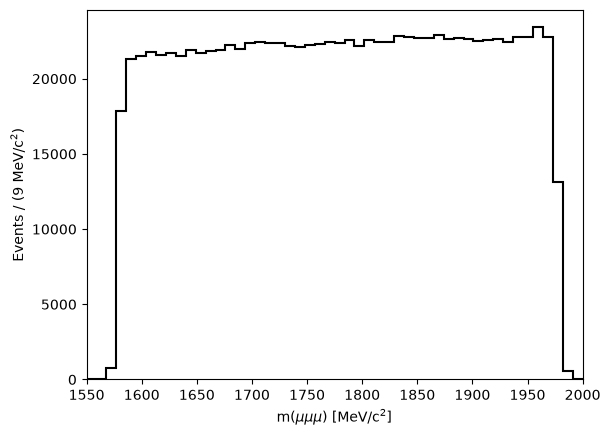

In [7]:
from analysis_helpers.plotting import plot_hist
fig, ax = plot_hist(df.Tau_M, bins=50, range=(1550, 2000), name=r'm($\mu\mu\mu$)', unit=r'MeV/c$^2$') 

In [8]:
import matplotlib.pyplot as plt

(<Axes: xlabel='$P_T$($\\mu\\mu\\mu$) [MeV/c]', ylabel='Events / (120 MeV/c)'>,
 <Axes: xlabel='$P_T$($\\mu\\mu\\mu$) [MeV/c]', ylabel='Events / (120 MeV/c)'>)

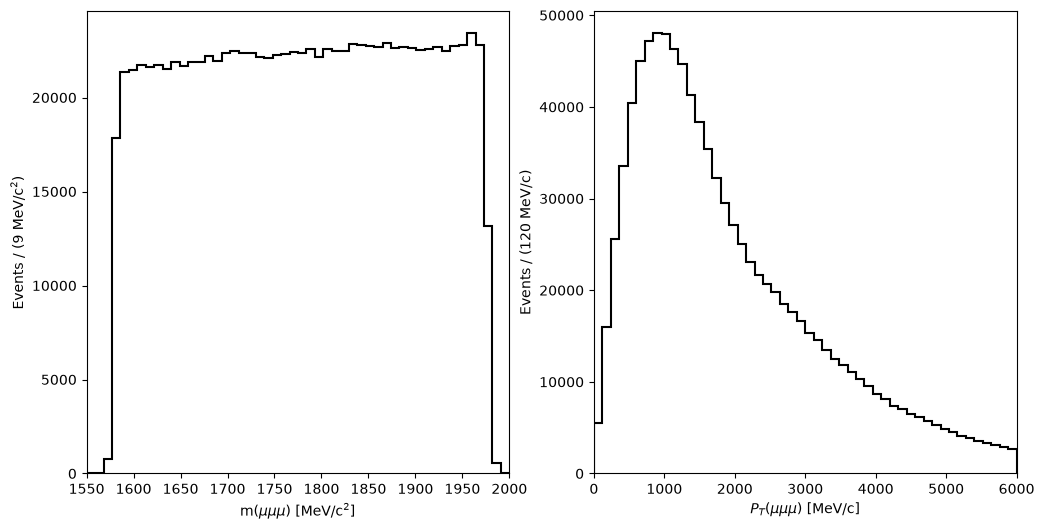

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_hist(df.Tau_M, bins=50, range=(1550, 2000), name=r'm($\mu\mu\mu$)', unit=r'MeV/c$^2$', ax=ax[0]) 
plot_hist(df.Tau_PT, bins=50, range=(0, 6000), name=r'$P_T$($\mu\mu\mu$)', unit=r'MeV/c', ax=ax[1]) 

From [LHCb Run 2 analysis](https://arxiv.org/pdf/2601.20785) (page 3):

"The signal sample is divided based on the three-muon mass Mμμμ into: a signal region,
where the signal selection efficiency, and the signal and background yields are evaluated,
defined as |Mμμμ − mτ | ≤ 20 MeV/c, with mτ being the known τ mass [9]; and a sideband region with |Mμμμ − mτ | > 20 MeV/c, which is used to model the background shape and
obtain an expectation of the background yield in the signal region."



Given the nominal $\tau$ mass of 1777 MeV/$c^2$, the resulting signal region is [1757, 1797] MeV/$c^2$.

In [10]:
from analysis_helpers.plotting import plot_vertical_lines

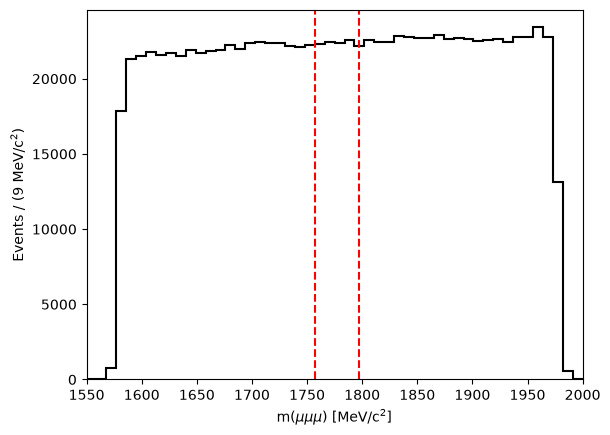

In [11]:
fig, ax = plot_hist(df.Tau_M, bins=50, range=(1550, 2000), name=r'm($\mu\mu\mu$)', unit=r'MeV/c$^2$') 
plot_vertical_lines(ax, xline=[1757, 1797], color='red', linestyle='--')

In [12]:
from analysis_helpers.plotting import plot_signal_and_backgrond_distributions

<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1286630/1449693150.py:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('$P_T$($\mu\mu\mu$) [MeV/$c$]')


Text(0, 0.5, 'Density')

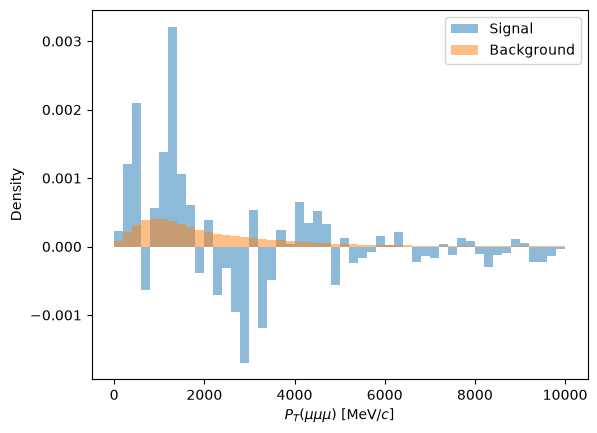

In [13]:
fig, ax = plot_signal_and_backgrond_distributions(df, 'Tau_PT', 'Tau_M', [1757, 1797], [[1600, 1757], [1797, 1950]], bins=50, range=(0, 10000))
ax.set_xlabel('$P_T$($\mu\mu\mu$) [MeV/$c$]')
ax.set_ylabel('Density')

### $D_s \to \phi\pi$ candidate

In [14]:
data['Ds2PhiPi/DecayTree'].keys()

['totCandidates',
 'nCandidate',
 'ALLPVCHI2_indx',
 'ALLPVCHI2',
 'ALLPVNDOF_indx',
 'ALLPVNDOF',
 'ALLPVX_indx',
 'ALLPVX',
 'ALLPVY_indx',
 'ALLPVY',
 'ALLPVZ_indx',
 'ALLPVZ',
 'BUNCHCROSSING_ID',
 'BUNCHCROSSING_TYPE',
 'BeamspotX',
 'BeamspotY',
 'BeamspotZ',
 'EVENTNUMBER',
 'FillNumber',
 'GPSTIME',
 'Hlt1BeamGasDecision',
 'Hlt1BeamOneDecision',
 'Hlt1BeamTwoDecision',
 'Hlt1BothBeamsDecision',
 'Hlt1GECPassthroughDecision',
 'Hlt1L02PPiDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice1_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice1_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice2_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice2_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice3_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice3_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice4_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice4_promptDecision',
 'Hlt1LowMassNoipDielectron_massSlice1_displacedDecisio

In [15]:
variables_to_plot_Ds = ['Ds_M', 'Ds_PT']
df_Ds = data['Ds2PhiPi/DecayTree'].arrays(variables_to_plot_Ds, library="pd")
print(df_Ds)

               Ds_M        Ds_PT
0       1806.181394  1296.303345
1       2071.834928  1106.689453
2       1869.514924  1521.965088
3       2161.985420  1097.410645
4       1738.835763   468.354309
...             ...          ...
112553  1862.360439  1610.476685
112554  1851.898494  1091.209717
112555  2127.060925  1466.426147
112556  2174.504746  1514.512329
112557  1818.271914   334.024719

[112558 rows x 2 columns]


(<Axes: xlabel='$P_T$($\\mu\\mu\\pi$) [MeV/c]', ylabel='Events / (120 MeV/c)'>,
 <Axes: xlabel='$P_T$($\\mu\\mu\\pi$) [MeV/c]', ylabel='Events / (120 MeV/c)'>)

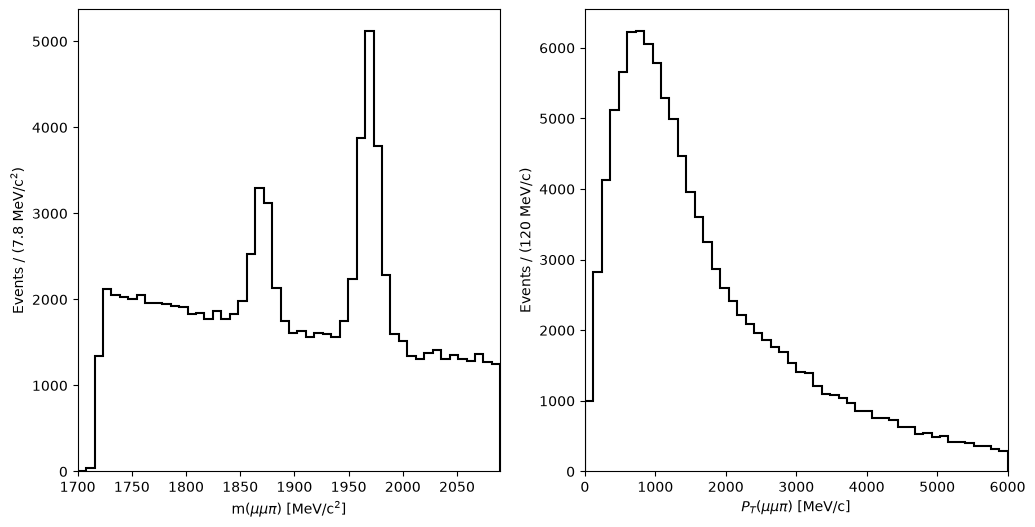

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_hist(df_Ds.Ds_M, bins=50, range=(1700, 2090), name=r'm($\mu\mu\pi$)', unit=r'MeV/c$^2$', ax=ax[0]) 
# Ds has mass=1968 -> second peak
plot_hist(df_Ds.Ds_PT, bins=50, range=(0, 6000), name=r'$P_T$($\mu\mu\pi$)', unit=r'MeV/c', ax=ax[1]) 

From [LHCb Run 2 analysis](https://arxiv.org/pdf/2601.20785) (page 3):

"In the selection of $D_s^-$ candidates, the $\mu^-\mu^+\pi^-$ mass is required to lie within $\pm 50$ MeV/$c^2$ of the known $D_s^-$ mass, while the $\mu^-\mu^+$ mass must fall within $\pm 20$ MeV/$c^2$ of the known $\phi$-meson mass"

Given the nominal $D_s$ mass of 1968 MeV/$c^2$, the resulting signal region is [1918, 2018] MeV/$c^2$

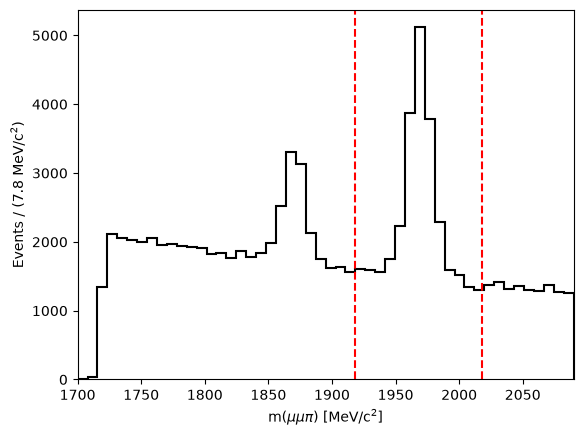

In [17]:
fig, ax = plot_hist(df_Ds.Ds_M, bins=50, range=(1700, 2090), name=r'm($\mu\mu\pi$)', unit=r'MeV/c$^2$') 
plot_vertical_lines(ax, xline=[1918, 2018], color='red', linestyle='--')

The left sideband boundary is restricted to exclude the $D^+$ mass peak, so that only true background is used for the subtraction.

<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1286630/4043338176.py:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('$P_T$($\mu\mu\pi$) [MeV/$c$]')


Text(0, 0.5, 'Density')

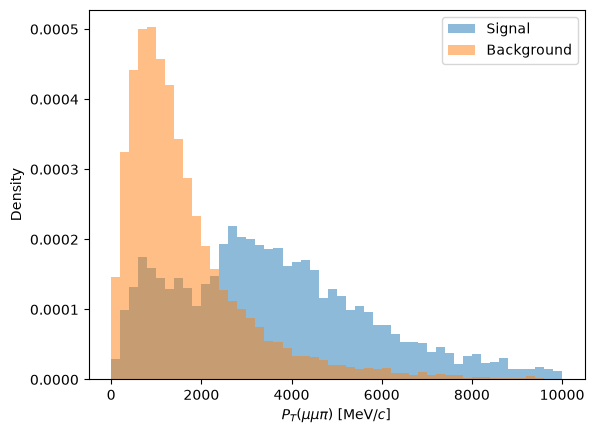

In [18]:
fig, ax = plot_signal_and_backgrond_distributions(df_Ds, 'Ds_PT', 'Ds_M', [1918, 2018], [[1890, 1918], [2018, 2150]], bins=50, range=(0, 10000))
ax.set_xlabel('$P_T$($\mu\mu\pi$) [MeV/$c$]')
ax.set_ylabel('Density')

# MC Samples

The MC samples are generated according to specific decay models, which are then reconstructed as the same as data in a simulation of the Run3 running detector.

The samples are identified by the *event ID* as follows:

| Event ID | Decay Mode |
| --- | --- |
| 21513012 | $b\to D^+\to\tau^+\nu_{\tau}$ |
| 21513013 | $D^+\to\tau^+\nu_{\tau}$ |
| 23173002 | $b\to D^+_s\to\phi(1020)\pi^+$ |
| 23173003 | $D^+_s\to\phi(1020)\pi^+$ |
| 23513015 | $b\to D^+_s\to\tau^+\nu_{\tau}$ |
| 23513016 | $D^+_s\to\tau^+\nu_{\tau}$ |
| 31113003 | $b\to \tau^-\bar{\nu}_{\tau}$ |

where the $b$ at the beginning of the decay mode indicates that the $D$ or $\tau$ particle is the product of a decay of particle containing a $b$ quark (*secondary* decays).

In [19]:
event_id = [21513012, 21513013, 23173002, 23173003, 23513015, 23513016, 31113003]

In [20]:
for event in event_id:
    data_MC = uproot.open(data_samples[f'mc-{event}'][0])
    print(data_MC.keys())

['MC_TauToMuMuMu;1', 'MC_TauToMuMuMu/MCDecayTree;1', 'Tau2MuMuMu;1', 'Tau2MuMuMu/DecayTree;1', 'Ds2PhiPi;1', 'Ds2PhiPi/DecayTree;1', 'MC_DsToMuMuPi;1', 'MC_DsToMuMuPi/MCDecayTree;1', 'FileSummaryRecord;1']
['MC_TauToMuMuMu;1', 'MC_TauToMuMuMu/MCDecayTree;1', 'Tau2MuMuMu;1', 'Tau2MuMuMu/DecayTree;1', 'Ds2PhiPi;1', 'Ds2PhiPi/DecayTree;1', 'MC_DsToMuMuPi;1', 'MC_DsToMuMuPi/MCDecayTree;1', 'FileSummaryRecord;1']
['MC_DsToMuMuPi;1', 'MC_DsToMuMuPi/MCDecayTree;1', 'Tau2MuMuMu;1', 'Tau2MuMuMu/DecayTree;1', 'Ds2PhiPi;1', 'Ds2PhiPi/DecayTree;1', 'FileSummaryRecord;1']
['MC_DsToMuMuPi;1', 'MC_DsToMuMuPi/MCDecayTree;1', 'Ds2PhiPi;1', 'Ds2PhiPi/DecayTree;1', 'Tau2MuMuMu;1', 'Tau2MuMuMu/DecayTree;1', 'FileSummaryRecord;1']
['MC_TauToMuMuMu;1', 'MC_TauToMuMuMu/MCDecayTree;1', 'Tau2MuMuMu;1', 'Tau2MuMuMu/DecayTree;1', 'Ds2PhiPi;1', 'Ds2PhiPi/DecayTree;1', 'MC_DsToMuMuPi;1', 'MC_DsToMuMuPi/MCDecayTree;1', 'FileSummaryRecord;1']
['MC_TauToMuMuMu;1', 'MC_TauToMuMuMu/MCDecayTree;1', 'Tau2MuMuMu;1', 'Tau2

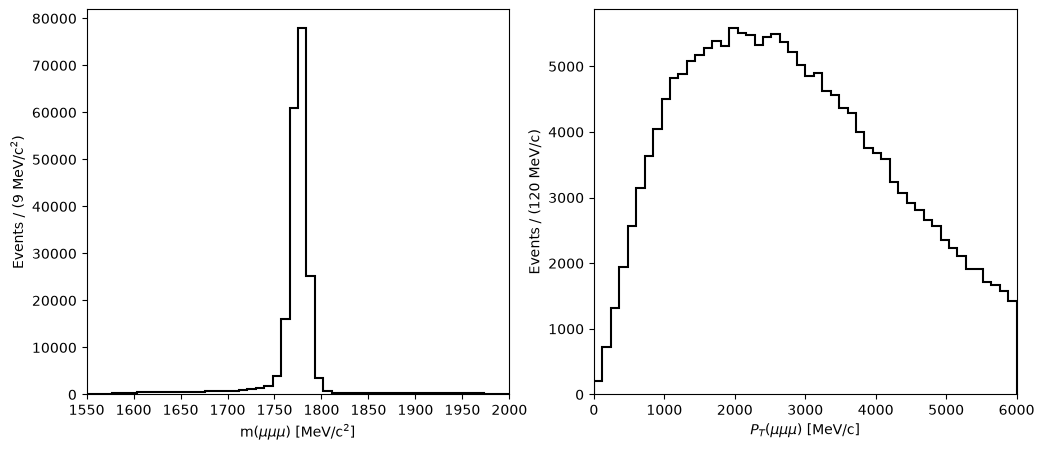

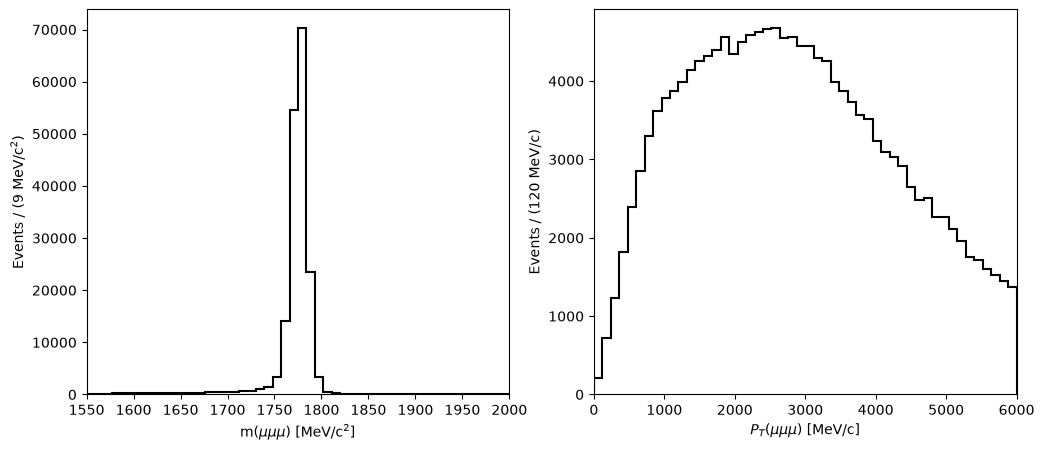

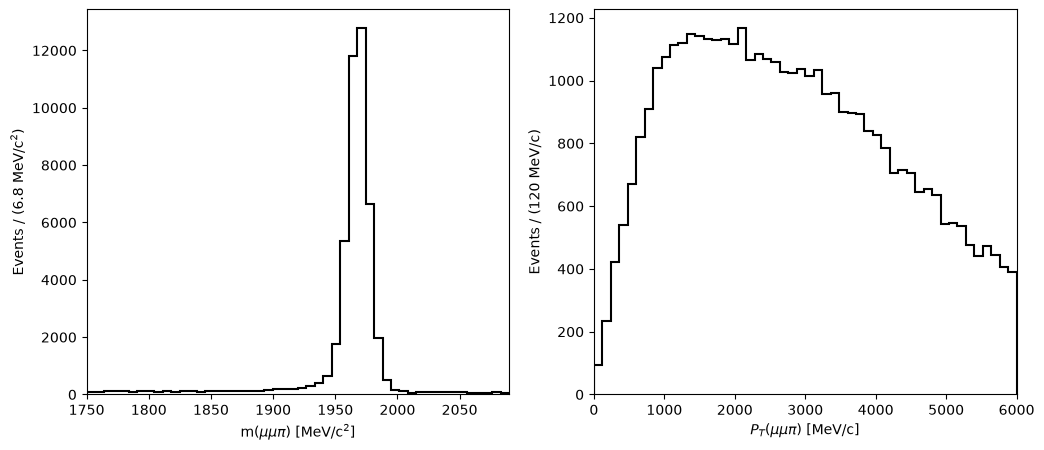

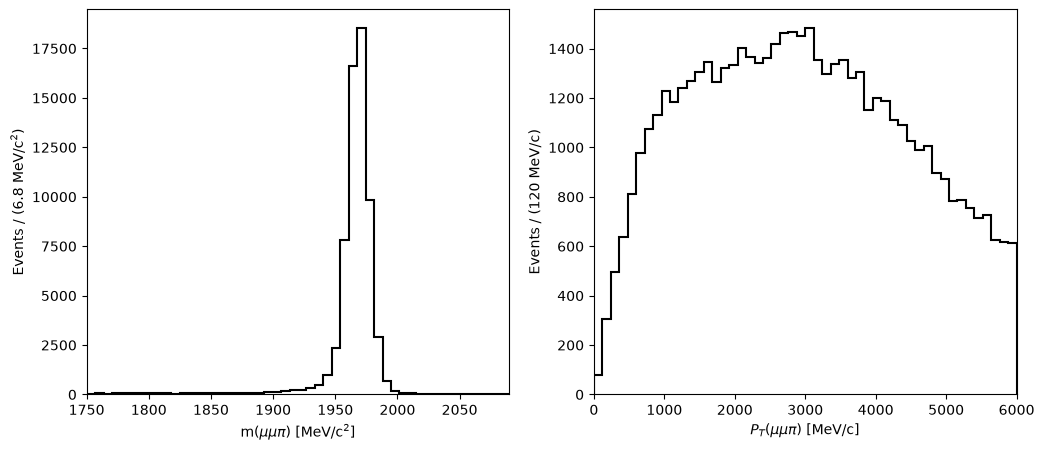

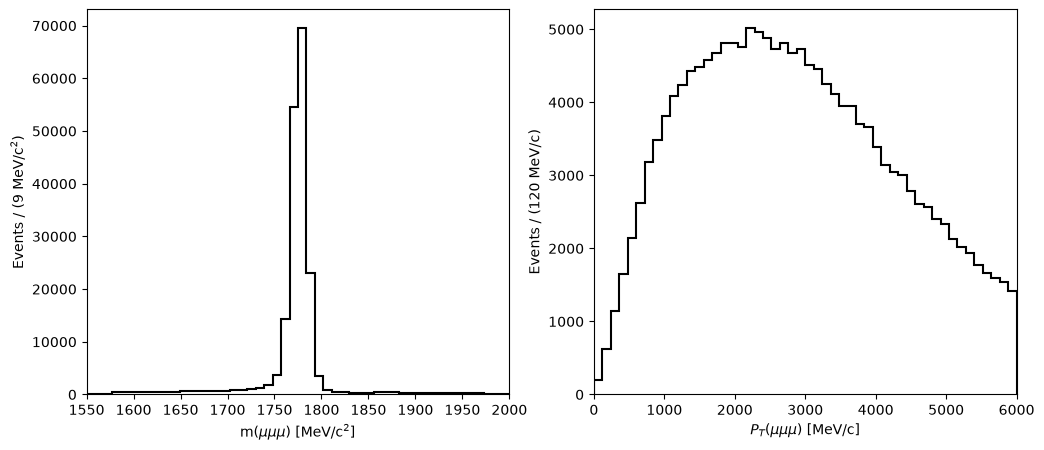

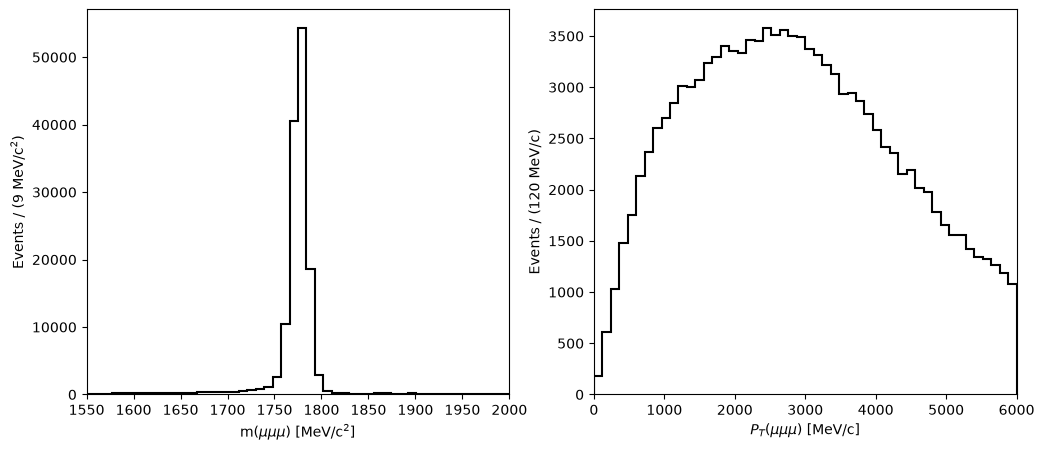

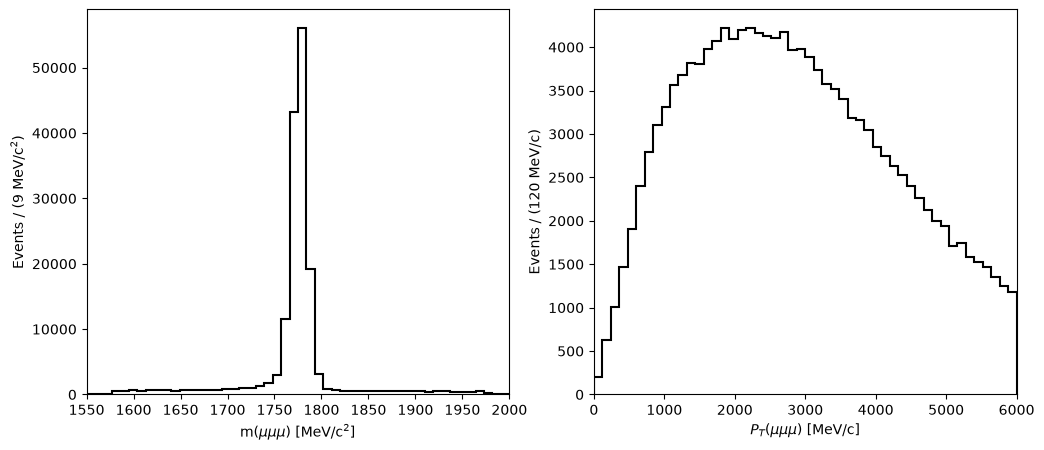

In [21]:
for event in event_id:

    data_MC = uproot.open(data_samples[f'mc-{event}'][0])

    if event in [23173002, 23173003]:
        tree = 'Ds2PhiPi/DecayTree'
        M, Pt = 'Ds_M', 'Ds_PT'
        M_name, Pt_name = r'm($\mu\mu\pi$)', r'$P_T$($\mu\mu\pi$)'
        M_range = (1750, 2090)

    else:
        tree = 'Tau2MuMuMu/DecayTree'
        M, Pt = 'Tau_M', 'Tau_PT'
        M_name, Pt_name = r'm($\mu\mu\mu$)', r'$P_T$($\mu\mu\mu$)'
        M_range = (1550, 2000)

    df_MC = data_MC[tree].arrays([M, Pt], library="pd")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    plot_hist(df_MC[M], bins=50, range=M_range, name=M_name, unit=r'MeV/c$^2$', ax=ax[0]) 
    plot_hist(df_MC[Pt], bins=50, range=(0, 6000), name=Pt_name, unit=r'MeV/c', ax=ax[1])